# Analysis of Nosofsky & Gold (2018)

Models: 
1. SCM & SCM-mix (from the paper)
2. TCC, TCC-mix (new)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import os

from models import SCM, SCM_mix, TCC, TCC_mix
from models import unpack_SCM_params, unpack_SCM_mix_params, unpack_TCC_params, unpack_TCC_mix_params
from models import init_coords_circle, coords_to_distances
from utils import (
    item_colors,
    load_data, extract_observed, prepare_data,
    validity_checks, fit_model,
    compute_aic_bic, print_model_comparison, compute_correlations,
    plot_predicted_vs_observed, plot_predicted_vs_observed_comparison,
    plot_aic_bic, plot_mds_solutions
)

# Config

In [153]:
# ADJUST FOR YOUR PURPOSES

# Set to None to fit all subjects or 
# specify a list of subject IDs to fit (e.g., [2, 4]; first subject has ID 1)
FIT_SUBJECTS = None

# Set to True to use the same MDS solution for all subjects (perfect circle)
# Or False to fit individual MDS coordinates for each subject
USE_SINGLE_MDS_SOLUTION = True

# Set to True to save results (model fits, predictions, plots)
SAVE_RESULTS = False

# Read model parameters if available
READ_PARAMS = True

In [ ]:
POSITIONS  = [3, 7, 11, 15]
SET_SIZES  = [2, 5, 8]
SUBJECTS   = range(1, 9)
N_SUBJECTS = len(SUBJECTS)
N_ITEMS    = 16
N_SS       = len(SET_SIZES)
N_POS      = len(POSITIONS)

# TCC-integration settings
N_POINTS = 100
X_RANGE  = (-3, 9)

# where to save results  
if SAVE_RESULTS:
    PATH = 'results/Fixed_MDS/' if USE_SINGLE_MDS_SOLUTION else 'results/Free_MDS/'
    PLOTS_PATH = os.path.join(PATH, 'Plots/')
else:
    PATH = None
    PLOTS_PATH = None

# Read Data

In [ ]:
data = load_data('Data', SET_SIZES, POSITIONS)

if FIT_SUBJECTS is not None:
    SUBJECTS = FIT_SUBJECTS
    N_SUBJECTS = len(SUBJECTS)

data_matrix   = extract_observed(data, SUBJECTS, SET_SIZES, POSITIONS)
prepared_data = prepare_data(data, SUBJECTS, SET_SIZES, POSITIONS)

In [ ]:
# Load model parameters from pickle if available
if READ_PARAMS:
    pickle_path = os.path.join(PATH, f'results.pkl')

    with open(pickle_path, 'rb') as f:
        results = pickle.load(f)

    # --- fits ---
    SCM_fit     = results['fits']['SCM']
    SCM_mix_fit = results['fits']['SCM-mix']
    TCC_fit     = results['fits']['TCC']
    TCC_mix_fit = results['fits']['TCC-mix']

    # --- predictions ---
    SCM_predictions     = results['predictions']['SCM']
    SCM_mix_predictions = results['predictions']['SCM-mix']
    TCC_predictions     = results['predictions']['TCC']
    TCC_mix_predictions = results['predictions']['TCC-mix']

    # --- comparison table ---
    comparison_df = results['comparison']
    
    # --- correlations ---
    correlations = results['correlations']

    # --- config ---
    SUBJECTS  = results['config']['SUBJECTS']
    SET_SIZES = results['config']['SET_SIZES']
    POSITIONS = results['config']['POSITIONS']
    N_POINTS  = results['config']['N_POINTS']
    X_RANGE   = results['config']['X_RANGE']
    N_SS      = len(SET_SIZES)
    N_POS     = len(POSITIONS)

    predictions_dict = {
        'SCM':     SCM_predictions,
        'SCM-mix': SCM_mix_predictions,
        'TCC':     TCC_predictions,
        'TCC-mix': TCC_mix_predictions,
    }

    print(f'Loaded from: {pickle_path}')
    print(f'Subjects: {list(SUBJECTS)}')
    print(f'Models: {list(results["fits"].keys())}')

# Optimization

In [125]:
total_counts  = data_matrix.sum()
coords_init_all = np.tile(init_coords_circle(), N_SUBJECTS)  # (N_SUBJECTS * 32,)

In [ ]:
def neg_log_likelihood(params, model, observed_counts, prep_data,
                       n_points=N_POINTS, x_range=X_RANGE,
                       mds_fixed=USE_SINGLE_MDS_SOLUTION):

    kwargs = dict(mds_fixed=mds_fixed)
    if not mds_fixed:
        kwargs['n_subjects'] = N_SUBJECTS

    if not validity_checks(params, model, mds_fixed=mds_fixed,
                           n_subjects=N_SUBJECTS):
        return 1e10
    
    # Predictions
    if model is SCM or model is SCM_mix:
        predicted_probs = model(params_vec=params, prepared_data=prep_data,
                                **kwargs)[0]
    elif model is TCC or model is TCC_mix:
        predicted_probs = model(params_vec=params, prepared_data=prep_data,
                                n_points=n_points, x_range=x_range,
                                **kwargs)[0]

    eps = 1e-12
    return -np.sum(observed_counts * np.log(predicted_probs + eps)) / total_counts

## SCM

In [ ]:
# Run only if we don't have pre-fitted parameters to load
if not READ_PARAMS:
    initial_params_SCM = np.concatenate([
        np.repeat(1/16, 15),
        [1.0],
        np.repeat(0.01, 3),
        coords_init_all if not USE_SINGLE_MDS_SOLUTION else [],
    ])
    bounds_SCM = (
        [(0, 1)]       * 15 +
        [(0, None)]         +
        [(0, None)]    * 3  +
        ([(None, None)] * 32 * N_SUBJECTS if not USE_SINGLE_MDS_SOLUTION else [])
    )

    SCM_fit = fit_model(loss_func=neg_log_likelihood,
                            initial_params=initial_params_SCM,
                            params_bounds=bounds_SCM,
                            model=SCM,
                            observed_counts=data_matrix,
                            prep_data=prepared_data,
                            mds_fixed=USE_SINGLE_MDS_SOLUTION)

In [ ]:
biases, B, c, coords = unpack_SCM_params(SCM_fit.x, mds_fixed=USE_SINGLE_MDS_SOLUTION, 
                                         n_subjects=N_SUBJECTS)
print(f'Total {len(SCM_fit.x)} free parameters')
print(f'Negative log-likelihood: {SCM_fit.fun:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'Boost B: {B:.3f}\n')
print(f'c per set size: {c.round(3)}')
if not USE_SINGLE_MDS_SOLUTION:
    print(f'\nMDS coordinates:\n{coords.round(3)}')

## SCM-mix

In [ ]:
# Run only if we don't have pre-fitted parameters to load
if not READ_PARAMS:
    initial_params_SCM_mix = np.concatenate([
        SCM_fit.x[:16],        # biases + B from SCM
        SCM_fit.x[16:19],      # c from SCM
        [0.9, 0.8, 0.7],       # p_mem
        [1.0],                 # gamma
        coords_init_all if not USE_SINGLE_MDS_SOLUTION else [],
    ])
    bounds_SCM_mix = (
        [(0, 1)]       * 15 +
        [(0, None)]         +
        [(0, None)]    * 3  +
        [(0, 1)]       * 3  +
        [(0, None)]         +
        ([(None, None)] * 32 * N_SUBJECTS if not USE_SINGLE_MDS_SOLUTION else [])
    )


    SCM_mix_fit = fit_model(loss_func=neg_log_likelihood,
                            initial_params=initial_params_SCM_mix,
                            params_bounds=bounds_SCM_mix,
                            model=SCM_mix,
                            observed_counts=data_matrix,
                            prep_data=prepared_data,
                            mds_fixed=USE_SINGLE_MDS_SOLUTION)

In [ ]:
biases, B, c, p_mem, gamma, coords = unpack_SCM_mix_params(SCM_mix_fit.x, mds_fixed=USE_SINGLE_MDS_SOLUTION, 
                                                           n_subjects=N_SUBJECTS)
print(f'Total {len(SCM_mix_fit.x)} free parameters')
print(f'Negative log-likelihood: {SCM_mix_fit.fun:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'Boost B: {B:.3f}\n')
print(f'c per set size: {c.round(3)}\n')
print(f'p_mem per set size: {p_mem.round(3)}\n')
print(f'Gamma: {gamma:.3f}')
if not USE_SINGLE_MDS_SOLUTION:
    print(f'\nMDS coordinates:\n{coords.round(3)}')

## TCC

In [ ]:
# Run only if we don't have pre-fitted parameters to load
if not READ_PARAMS:
    initial_params_TCC = np.concatenate([
        [3.0],                 # d_prime_base
        [0.7, 0.5],            # d_scales for ss=5, ss=8
        [0.01],                # c
        np.repeat(0.0, 16),    # biases
        [0.5],                 # hp_boost
        coords_init_all if not USE_SINGLE_MDS_SOLUTION else [],
    ])
    bounds_TCC = (
        [(0, None)]         +
        [(0, 1)]       * 2  +
        [(0, None)]         +
        [(None, None)] * 16 +
        [(0, None)]         +
        ([(None, None)] * 32 * N_SUBJECTS if not USE_SINGLE_MDS_SOLUTION else [])
    )

    TCC_fit = fit_model(loss_func=neg_log_likelihood,
                        initial_params=initial_params_TCC,
                        params_bounds=bounds_TCC,
                        model=TCC,
                        observed_counts=data_matrix,
                        prep_data=prepared_data,
                        n_points=N_POINTS, x_range=X_RANGE,
                        mds_fixed=USE_SINGLE_MDS_SOLUTION)

In [ ]:
d_prime_base, d_scales, c, biases, hp_boost, coords = unpack_TCC_params(TCC_fit.x, mds_fixed=USE_SINGLE_MDS_SOLUTION, 
                                                                        n_subjects=N_SUBJECTS)
print(f'Total {len(TCC_fit.x)} free parameters')
print(f'Negative log-likelihood: {TCC_fit.fun:.3f}\n')
print(f"Base d': {d_prime_base:.3f}\n")
print("d' scales per set size:")
for ss, scale in zip(SET_SIZES, d_scales):
    print(f"  SS={ss}: scale={scale:.3f}  (d'={d_prime_base*scale:.3f})")
print(f'\nc: {c:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'HP boost: {hp_boost:.3f}')
if not USE_SINGLE_MDS_SOLUTION:
    print(f'\nMDS coordinates:\n{coords.round(3)}')

## TCC-mix

In [ ]:
# Run only if we don't have pre-fitted parameters to load
if not READ_PARAMS:
    # TCC-mix has many parameters, so we give it more room 
    # to find a good fit by increasing max iterations and function evaluations
    warmup_options = {'ftol': 1e-9, 'gtol': 1e-3, 'maxiter': 5000,  'maxfun': 200000}
    final_options  = {'ftol': 1e-9, 'gtol': 1e-3, 'maxiter': 50000, 'maxfun': 1000000}

    initial_params_TCC_mix = np.concatenate([
        [TCC_fit.x[0]],        # d_prime_base
        TCC_fit.x[1:3],        # d_scales
        [TCC_fit.x[3]],        # c
        TCC_fit.x[4:20],       # biases
        [TCC_fit.x[20]],       # hp_boost
        [0.9, 0.8, 0.7],       # p_mem
        [1.0],                 # gamma
        coords_init_all if not USE_SINGLE_MDS_SOLUTION else [],
    ])
    bounds_TCC_mix = (
        [(0, None)]         +
        [(0, 1)]       * 2  +
        [(0, None)]         +
        [(None, None)] * 16 +
        [(0, None)]         +
        [(0, 1)]       * 3  +
        [(0, None)]         +
        ([(None, None)] * 32 * N_SUBJECTS if not USE_SINGLE_MDS_SOLUTION else [])
    )

    TCC_mix_fit = fit_model(loss_func=neg_log_likelihood,
                            initial_params=initial_params_TCC_mix,
                            params_bounds=bounds_TCC_mix,
                            model=TCC_mix,
                            observed_counts=data_matrix,
                            prep_data=prepared_data,
                            n_points=N_POINTS, x_range=X_RANGE,
                            mds_fixed=USE_SINGLE_MDS_SOLUTION,
                            warmup_options=warmup_options,
                            final_options=final_options)

In [ ]:
d_prime_base, d_scales, c, biases, hp_boost, p_mem, gamma, coords = \
    unpack_TCC_mix_params(TCC_mix_fit.x, mds_fixed=USE_SINGLE_MDS_SOLUTION, 
                          n_subjects=N_SUBJECTS)
print(f'Total {len(TCC_mix_fit.x)} free parameters')
print(f'Negative log-likelihood: {TCC_mix_fit.fun:.3f}\n')
print(f"Base d': {d_prime_base:.3f}\n")
print("d' scales per set size:")
for ss, scale in zip(SET_SIZES, d_scales):
    print(f"  SS={ss}: scale={scale:.3f}  (d'={d_prime_base*scale:.3f})")
print(f'\nc: {c:.3f}\n')
print(f'Biases:\n{biases.round(3)}\n')
print(f'HP boost: {hp_boost:.3f}\n')
print(f'p_mem per set size: {p_mem.round(3)}\n')
print(f'Gamma: {gamma:.3f}')
if not USE_SINGLE_MDS_SOLUTION:
    print(f'\nMDS coordinates:\n{coords.round(3)}')

# Model Comparison

## AIC & BIC

Model                  n_params      NLL           AIC      AIC_best       BIC      BIC_best
-----------------------------------------------------------------------------------------------
SCM                      19         43162.77     86363.54                86521.13               
SCM-mix                  23         40805.75     81657.51     ***        81848.28     ***       
TCC                      21         41129.66     82301.32                82475.50               
TCC-mix                  25         41120.27     82290.55                82497.91               
Saved: results/Fixed_MDS/Plots/AIC_BIC.png


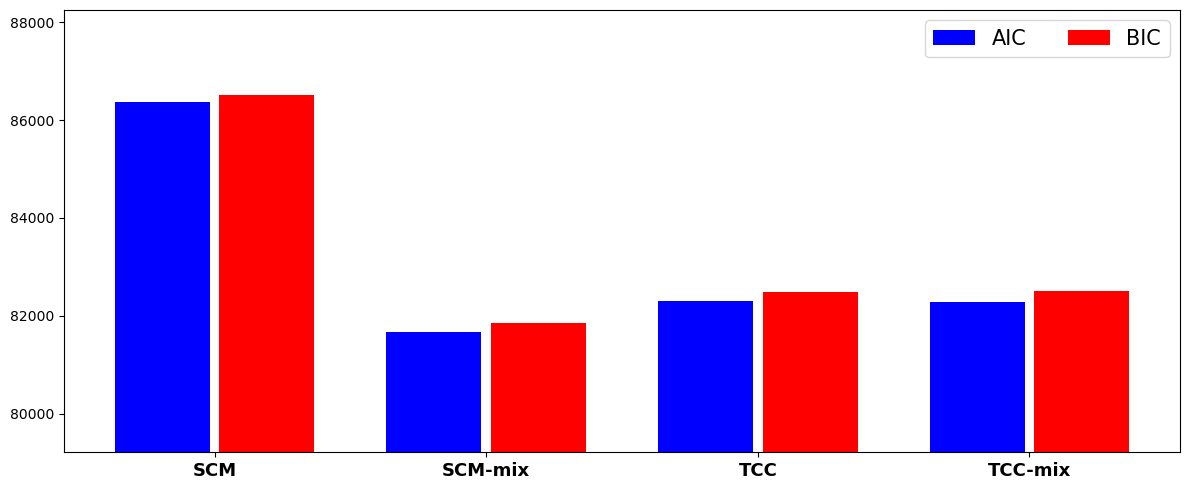

In [143]:
models_fit = {
    'SCM':     SCM_fit,
    'SCM-mix': SCM_mix_fit,
    'TCC':     TCC_fit,
    'TCC-mix': TCC_mix_fit,
}

comparison_df = print_model_comparison(models_fit, total_counts)
plot_aic_bic(comparison_df, save_path=PLOTS_PATH)

## Predictions

In [144]:
SCM_predictions     = SCM(SCM_fit.x, prepared_data, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS)
SCM_mix_predictions = SCM_mix(SCM_mix_fit.x, prepared_data, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS)
TCC_predictions     = TCC(TCC_fit.x, prepared_data, n_points=N_POINTS, x_range=X_RANGE, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS)
TCC_mix_predictions = TCC_mix(TCC_mix_fit.x, prepared_data, n_points=N_POINTS, x_range=X_RANGE, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS)

predictions_dict = {
    'SCM':     SCM_predictions,
    'SCM-mix': SCM_mix_predictions,
    'TCC':     TCC_predictions,
    'TCC-mix': TCC_mix_predictions,
}

## Correlations

In [145]:
correlations = {}
for name, (pred_probs, _) in predictions_dict.items():
    print(f"{'='*30} Correlations for {name} {'='*30}")
    correlations[name] = compute_correlations(pred_probs, data_matrix, 
                                              SET_SIZES, POSITIONS, SUBJECTS, N_SS, N_POS)
    print("\n")

============================== Correlations for SCM ==============================
Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.964    p=0.000
SS=2, Pos=7        r=0.977    p=0.000
SS=2, Pos=11       r=0.962    p=0.000
SS=2, Pos=15       r=0.965    p=0.000
SS=5, Pos=3        r=0.941    p=0.000
SS=5, Pos=7        r=0.946    p=0.000
SS=5, Pos=11       r=0.927    p=0.000
SS=5, Pos=15       r=0.931    p=0.000
SS=8, Pos=3        r=0.929    p=0.000
SS=8, Pos=7        r=0.936    p=0.000
SS=8, Pos=11       r=0.938    p=0.000
SS=8, Pos=15       r=0.925    p=0.000


============================== Correlations for SCM-mix ==============================
Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.983    p=0.000
SS=2, Pos=7        r=0.988    p=0.000
SS=2, Pos=11       r=0.984    p=0.000
SS=2, Pos=15       r=0.986    p=0.000
SS=5, Pos=3        r=0.975    p=

## Visualization

Saved: results/Fixed_MDS/Plots/SCM.png


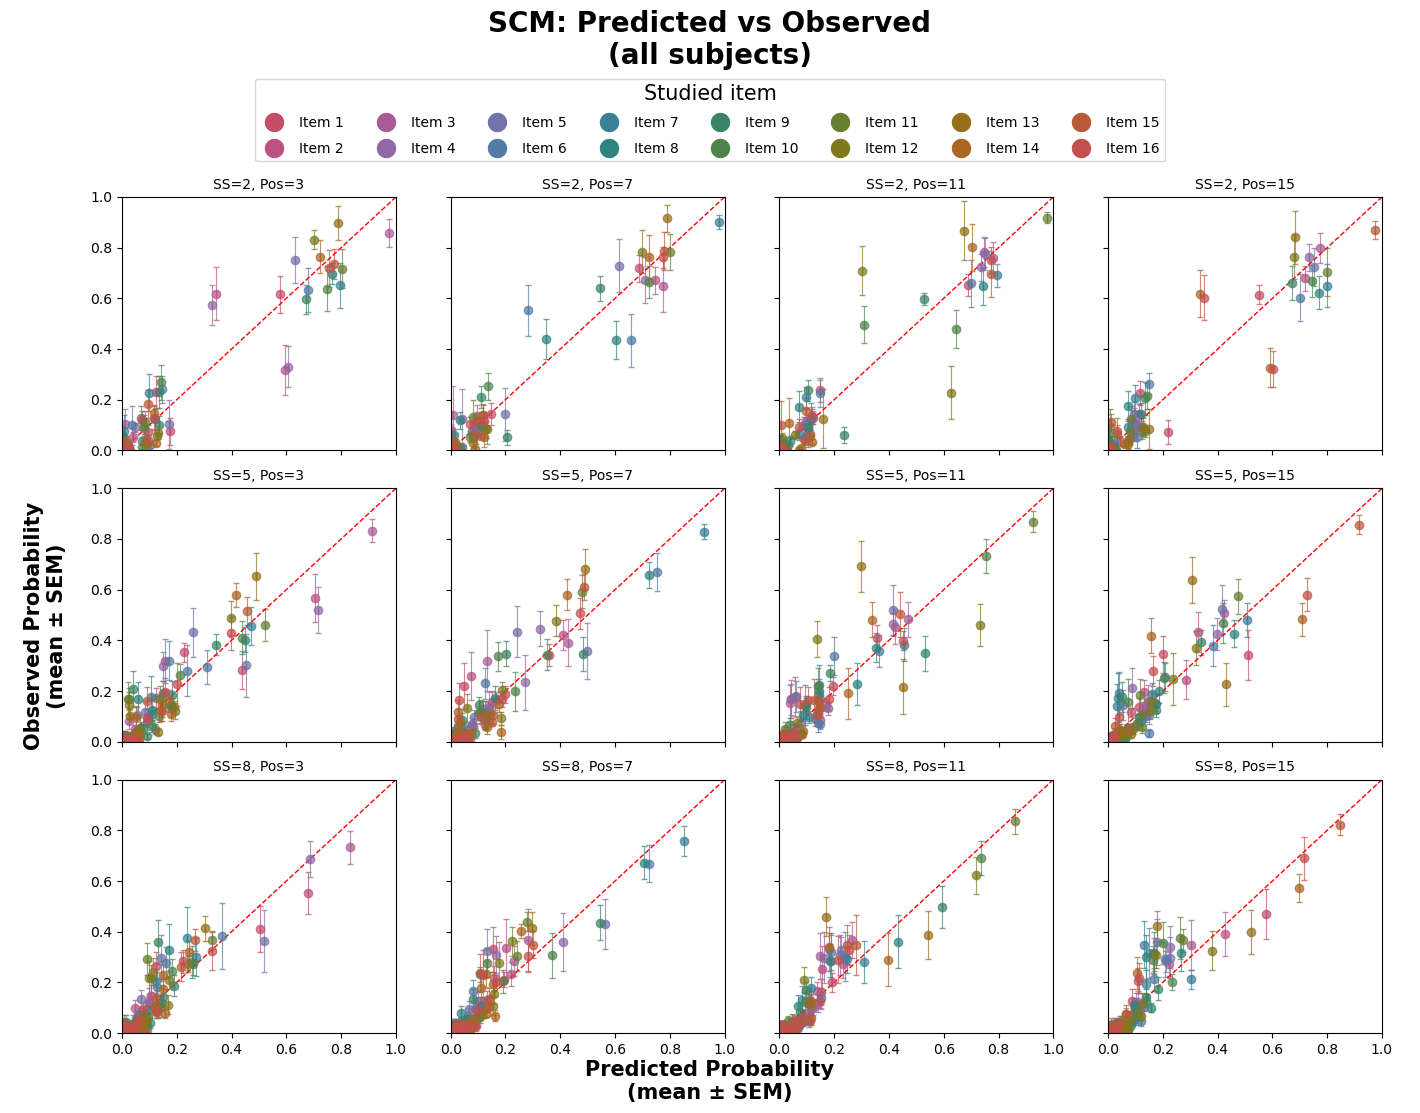

Saved: results/Fixed_MDS/Plots/SCM-mix.png


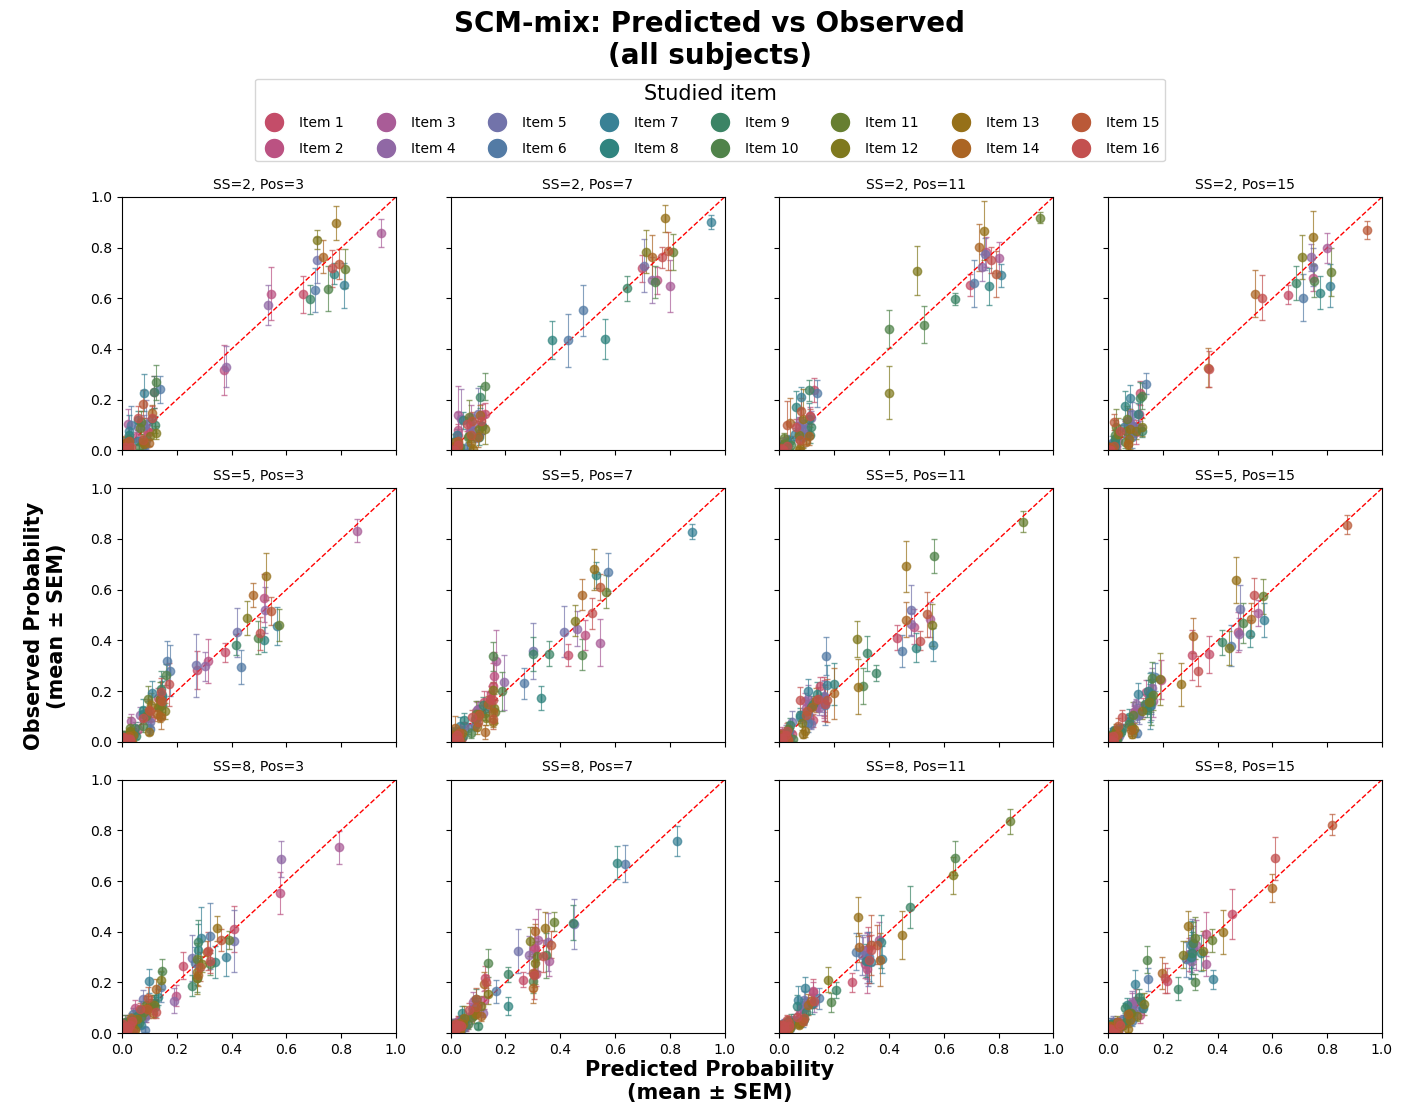

Saved: results/Fixed_MDS/Plots/TCC.png


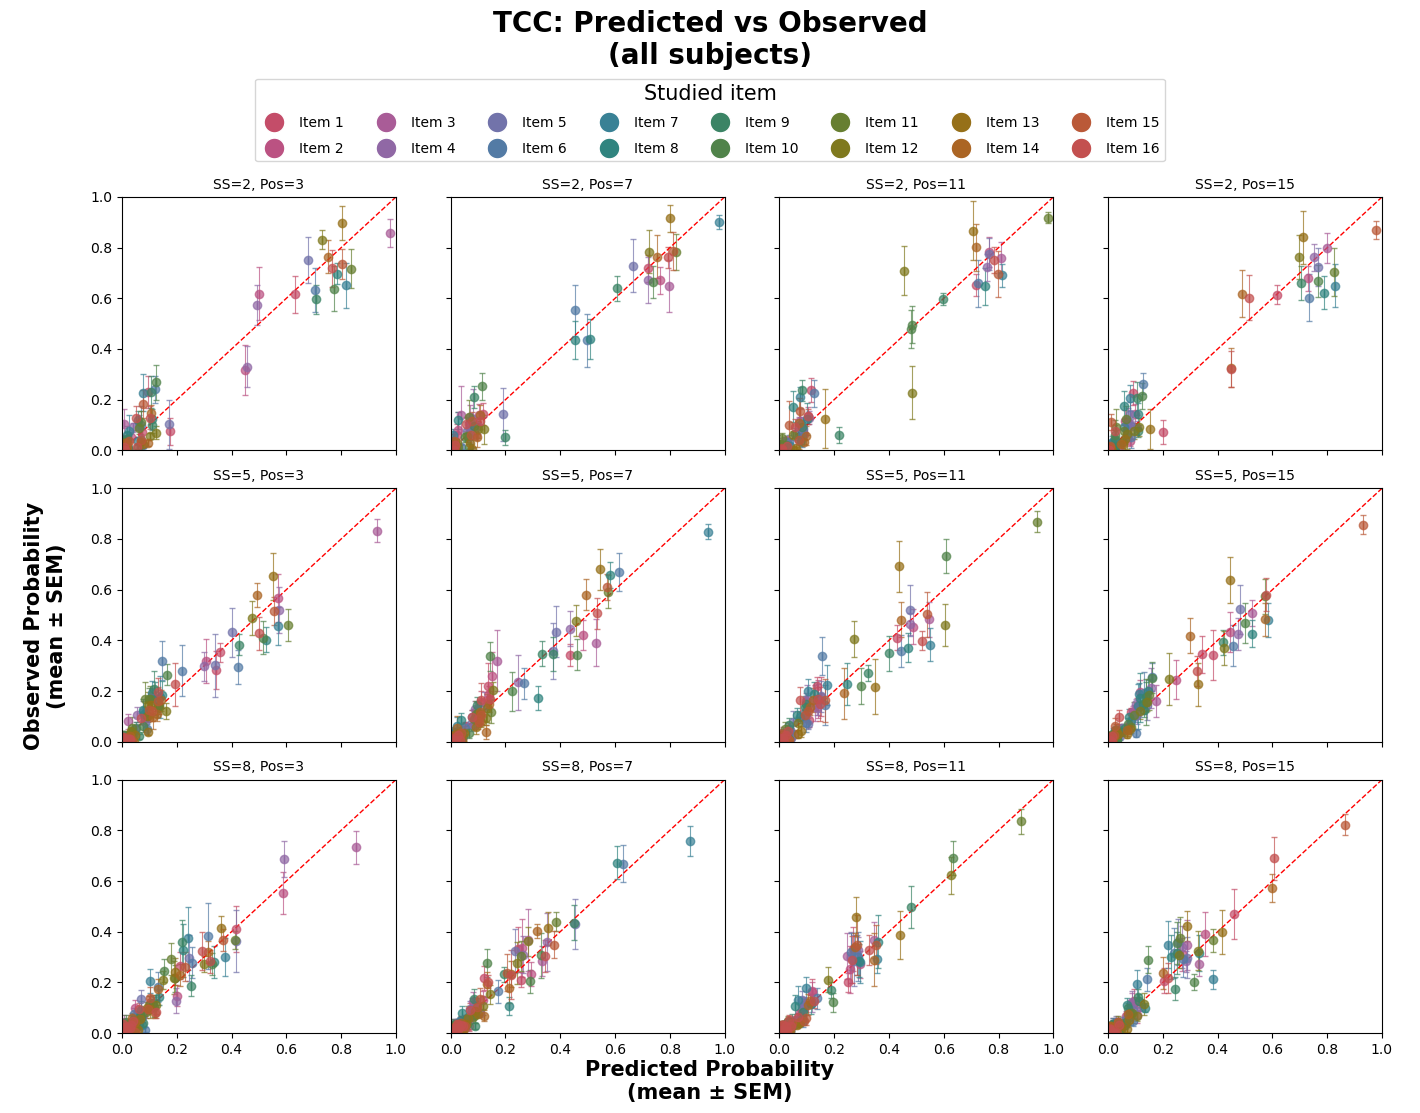

Saved: results/Fixed_MDS/Plots/TCC-mix.png


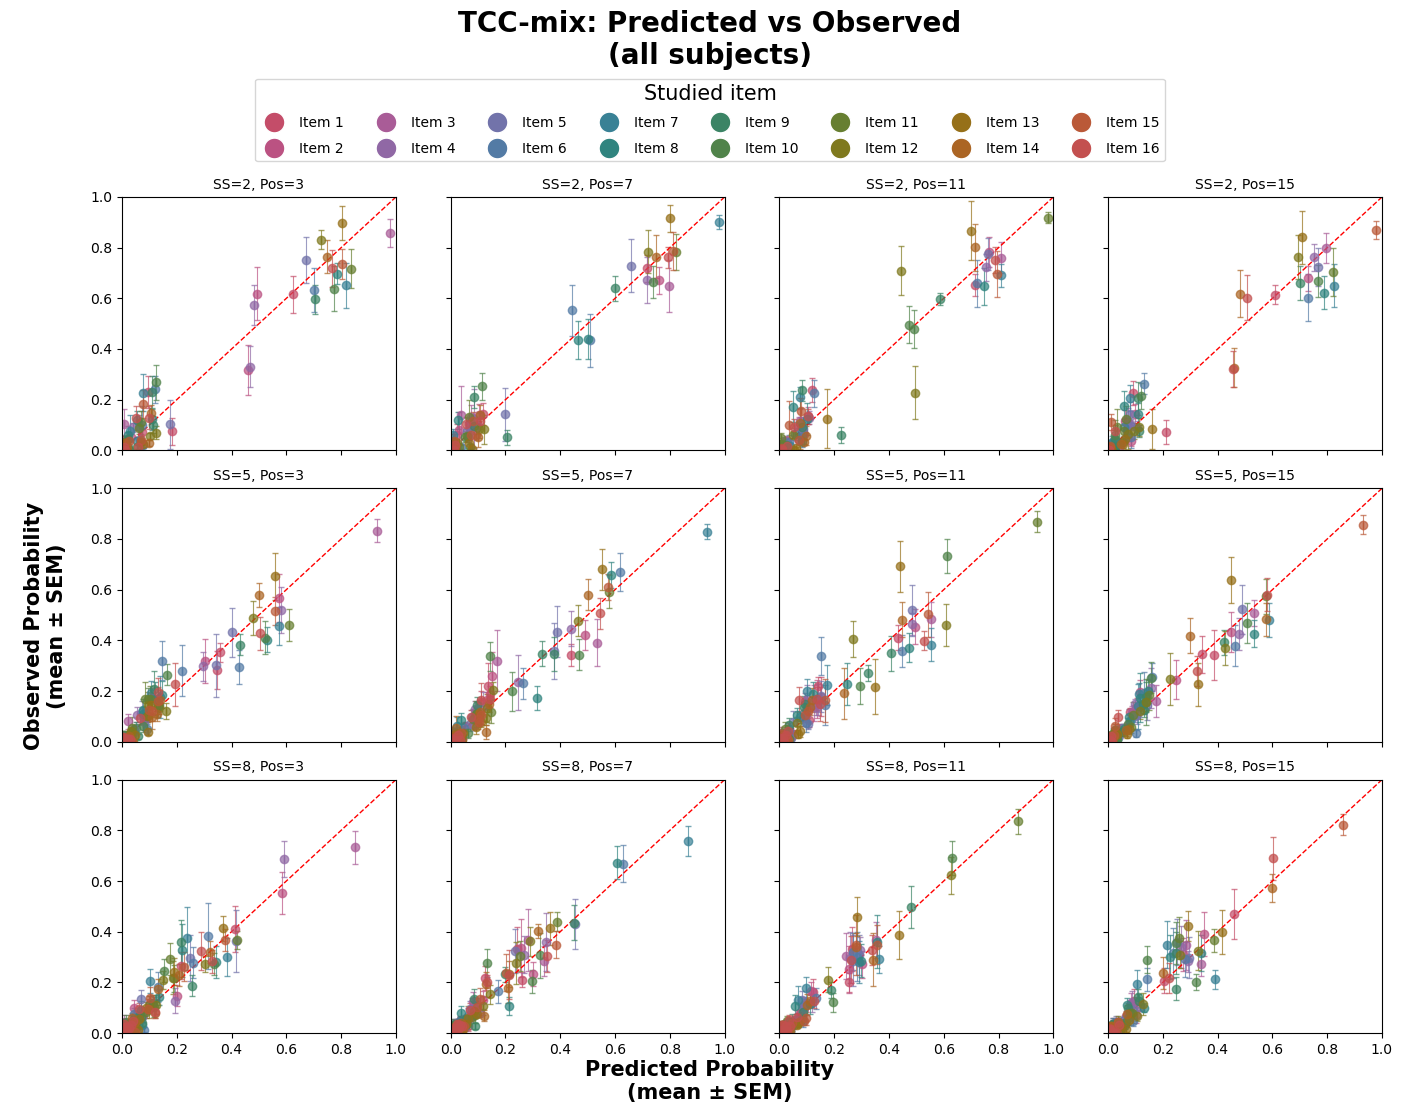

In [146]:
# Per-condition predicted vs observed (one plot per model)
for name, (pred_probs, _) in predictions_dict.items():
    plot_predicted_vs_observed(
        pred_probs, data_matrix, SET_SIZES, POSITIONS, SUBJECTS,
        N_SS, N_POS, model_name=name, error_type='sem',
        save_path=PLOTS_PATH
    )

Saved: results/Fixed_MDS/Plots/all_models_pred_vs_obs.png


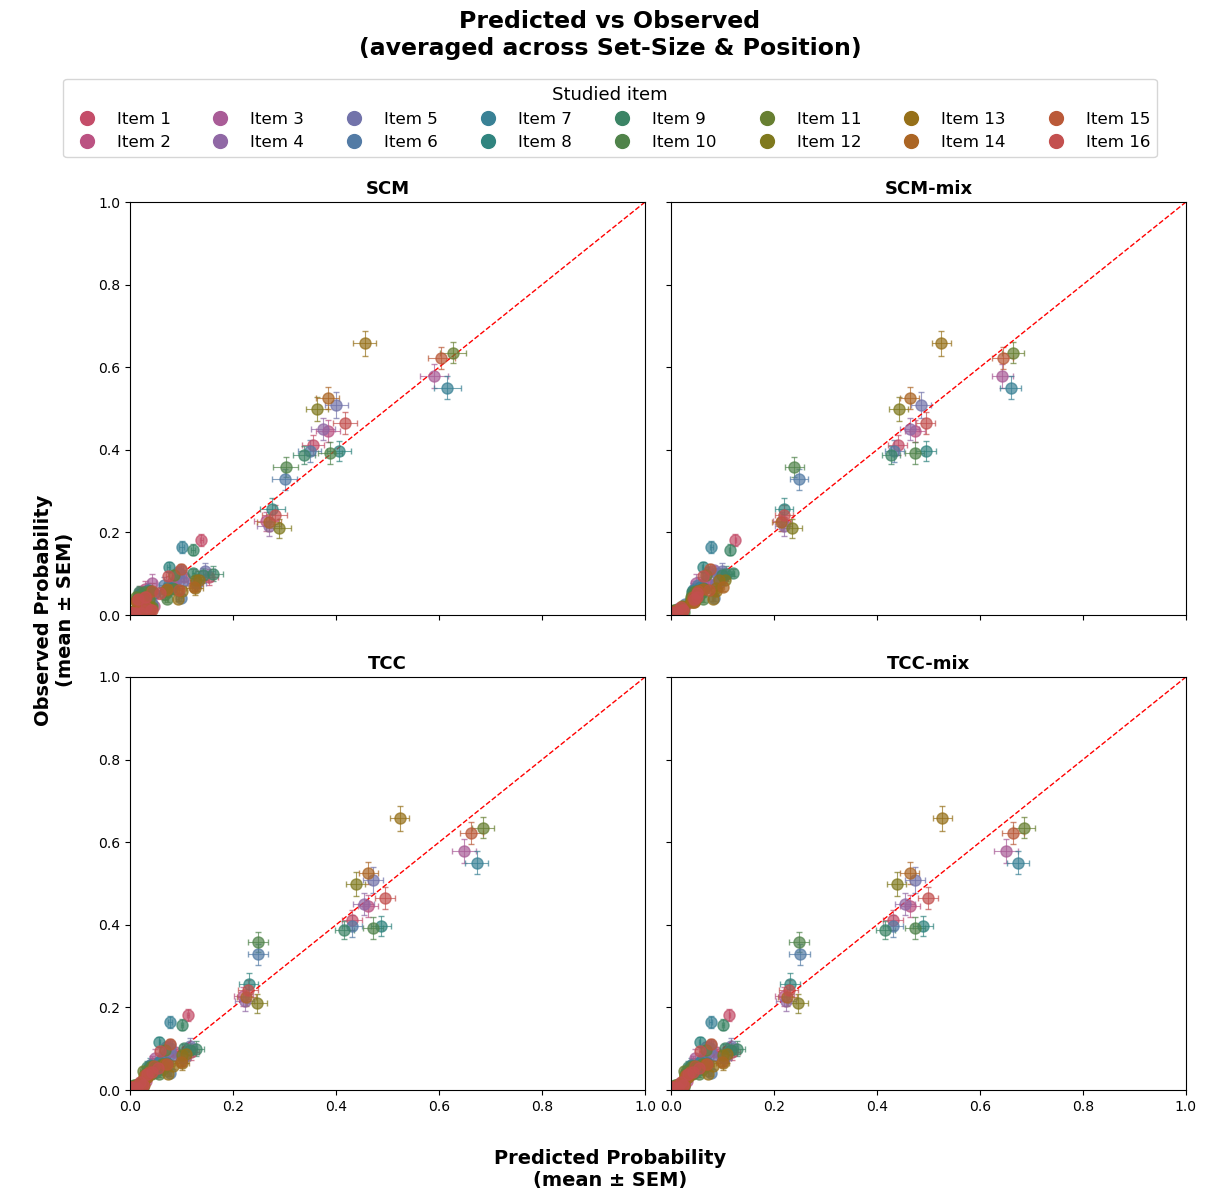

In [147]:
# Side-by-side model comparison
plot_predicted_vs_observed_comparison(
    predictions_dict, data_matrix,
    SUBJECTS, N_SS, N_POS,
    layout=[['SCM', 'SCM-mix'], ['TCC', 'TCC-mix']],
    error_type='sem',
    save_path=PLOTS_PATH
)

Saved: results/Fixed_MDS/Plots/SCM_MDS_solutions.png


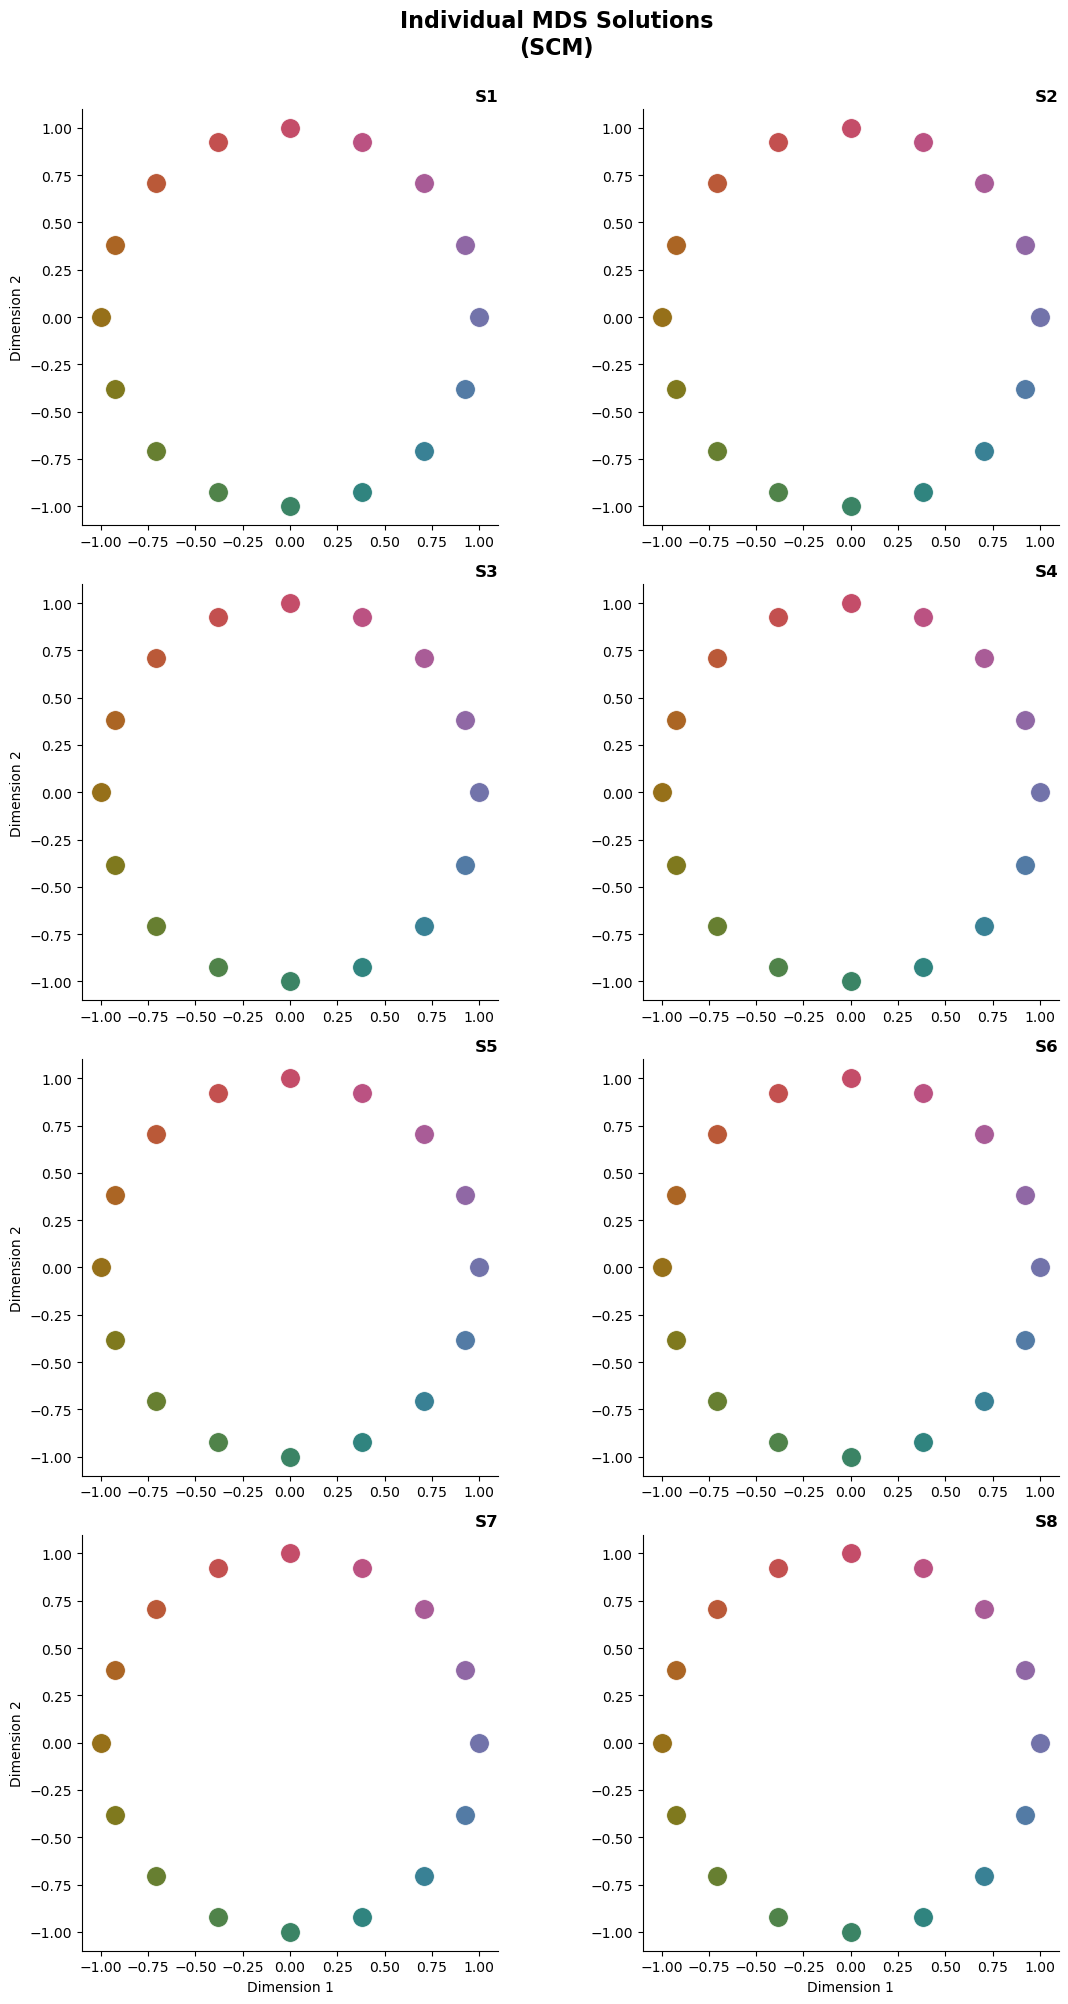

Saved: results/Fixed_MDS/Plots/SCM-mix_MDS_solutions.png


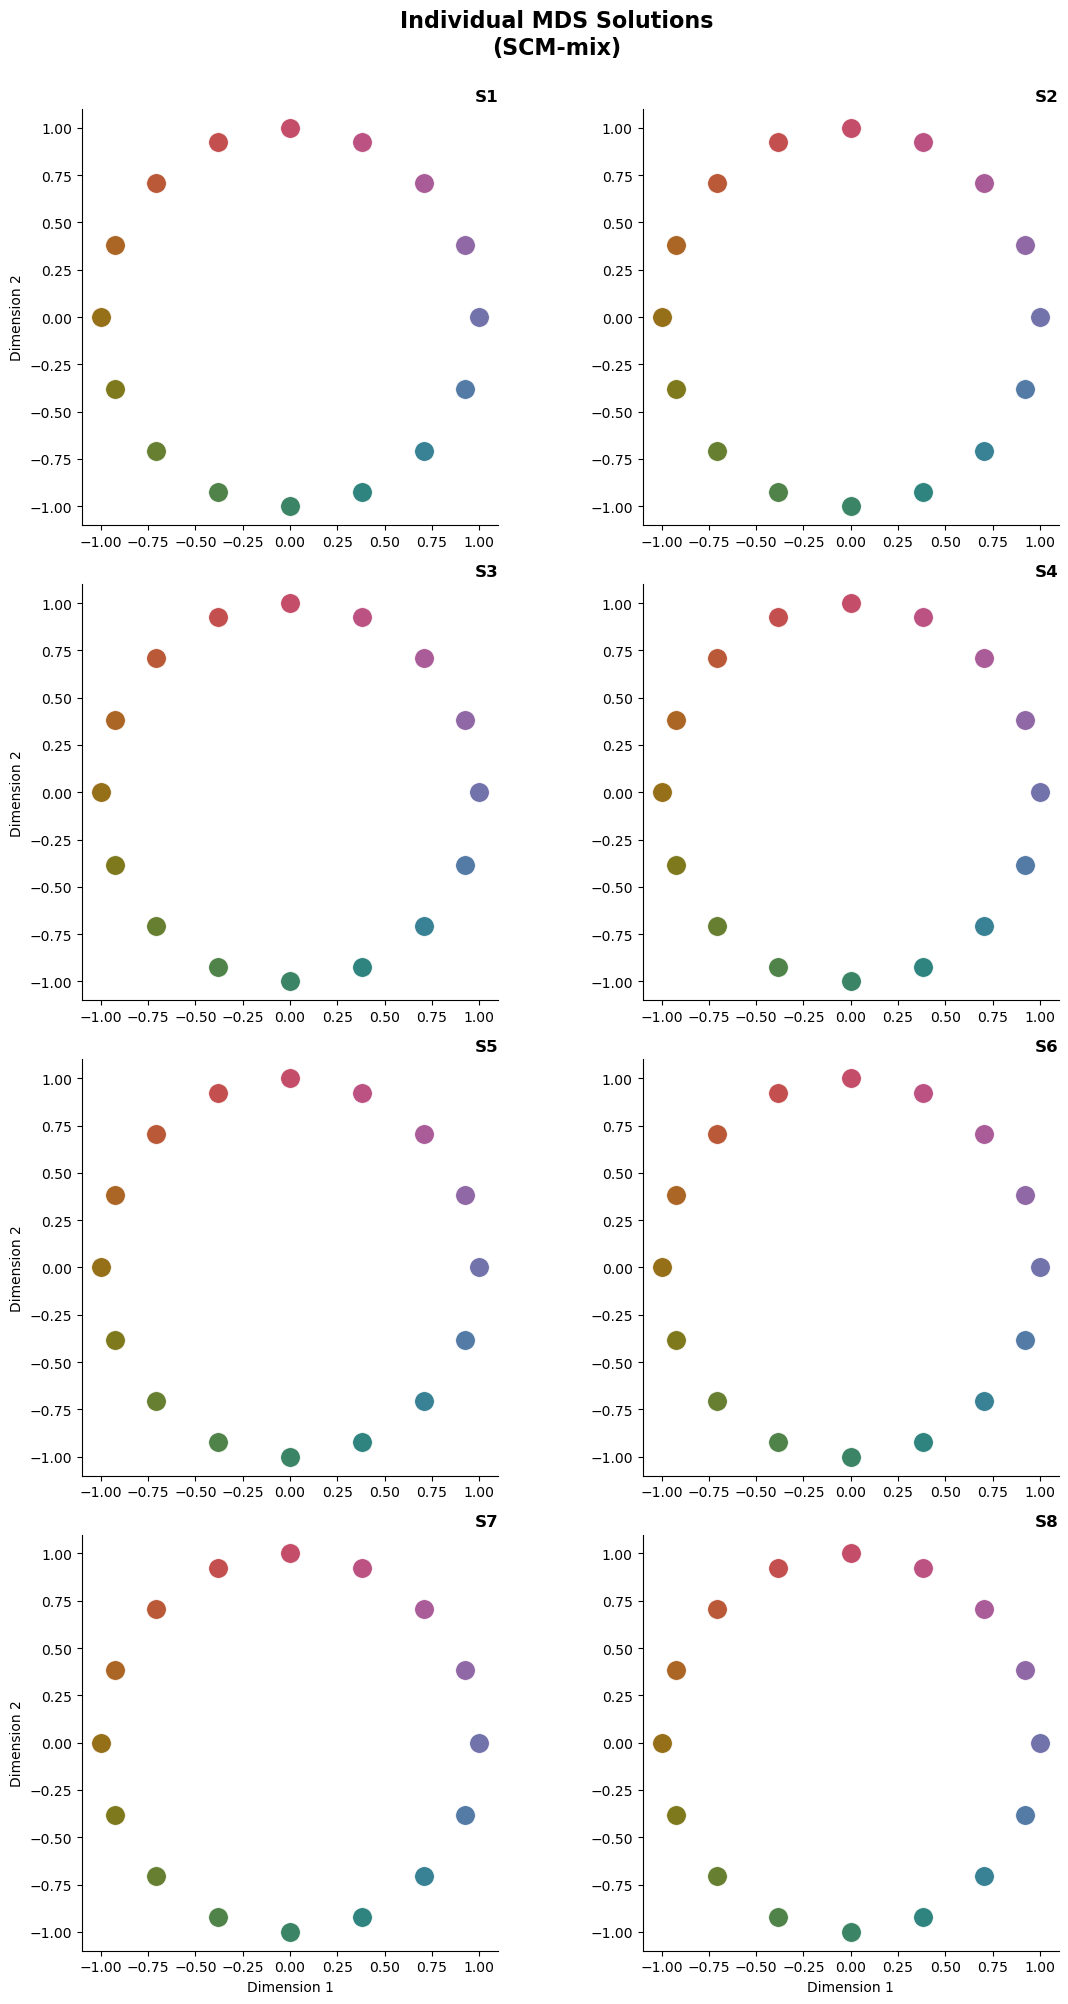

Saved: results/Fixed_MDS/Plots/TCC_MDS_solutions.png


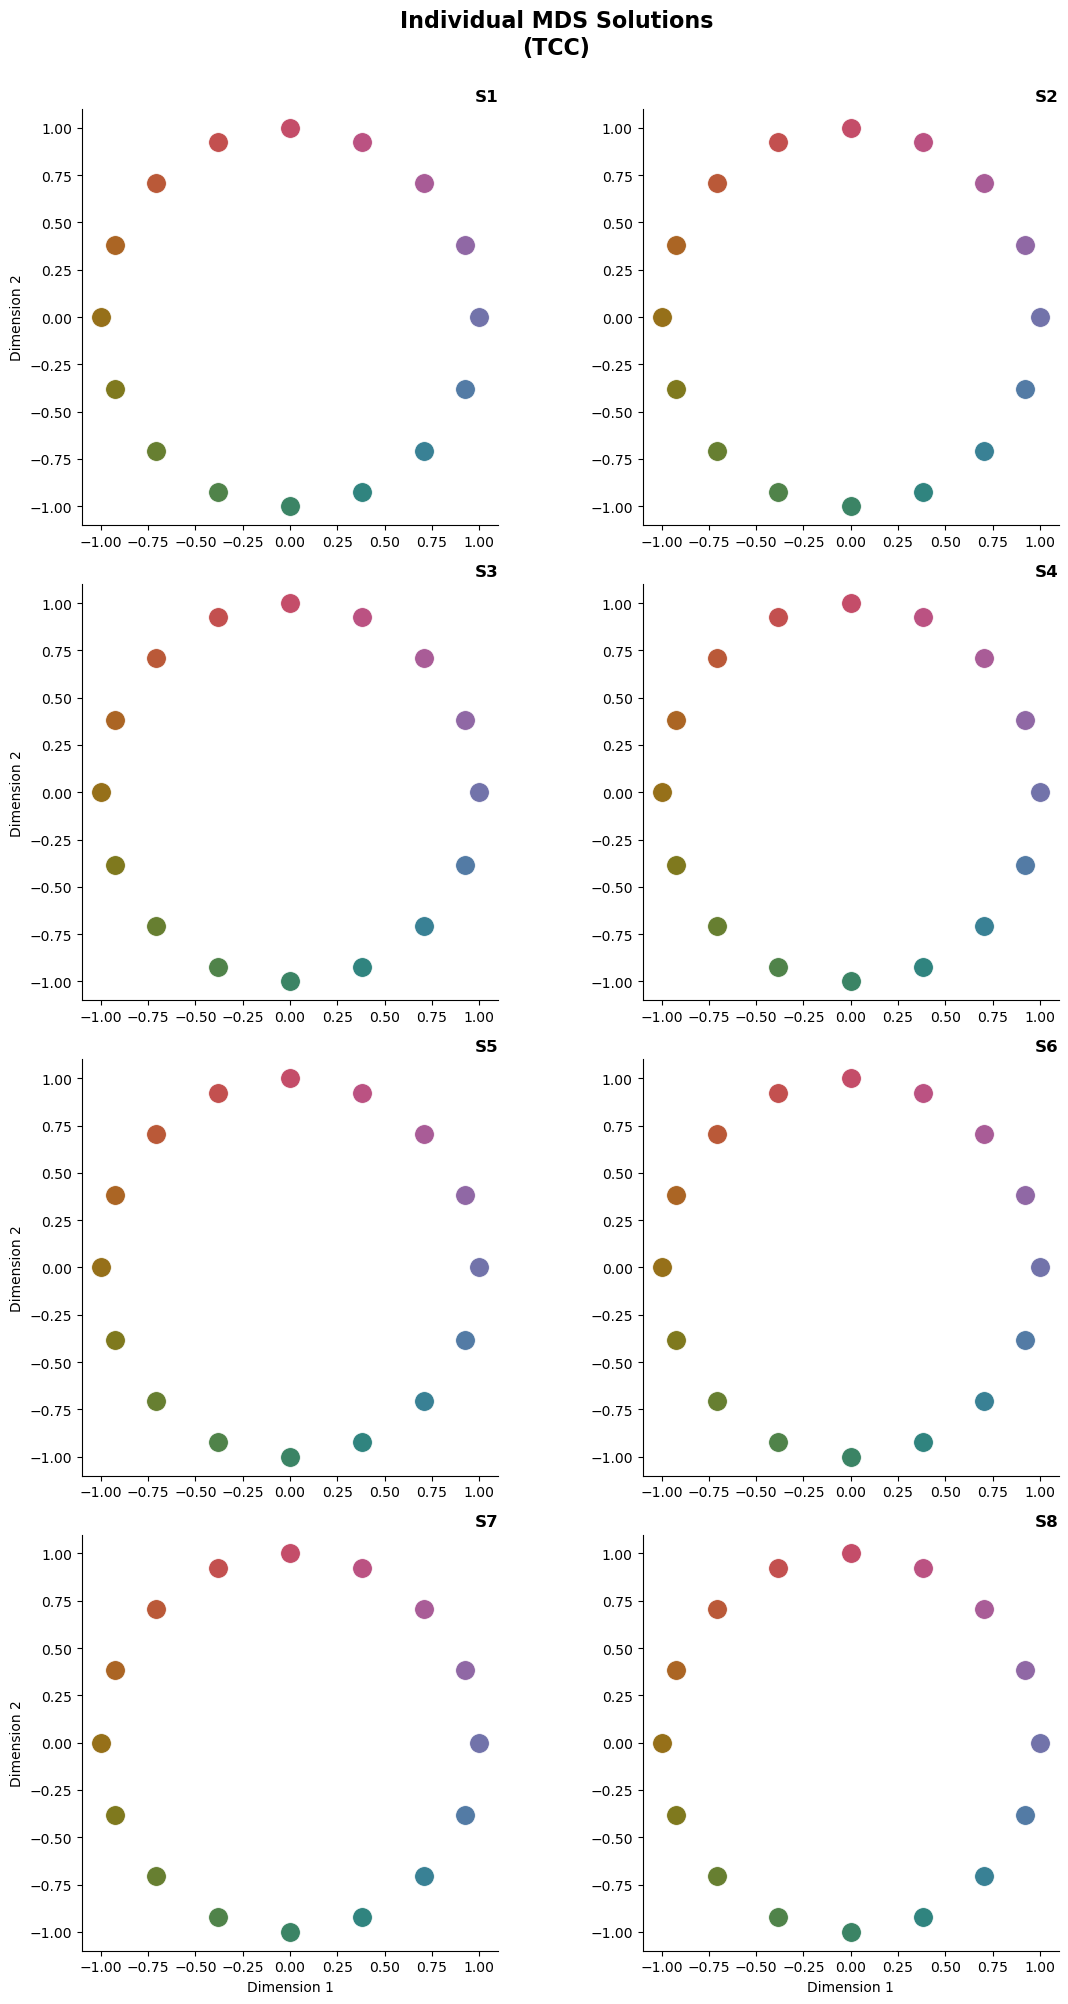

Saved: results/Fixed_MDS/Plots/TCC-mix_MDS_solutions.png


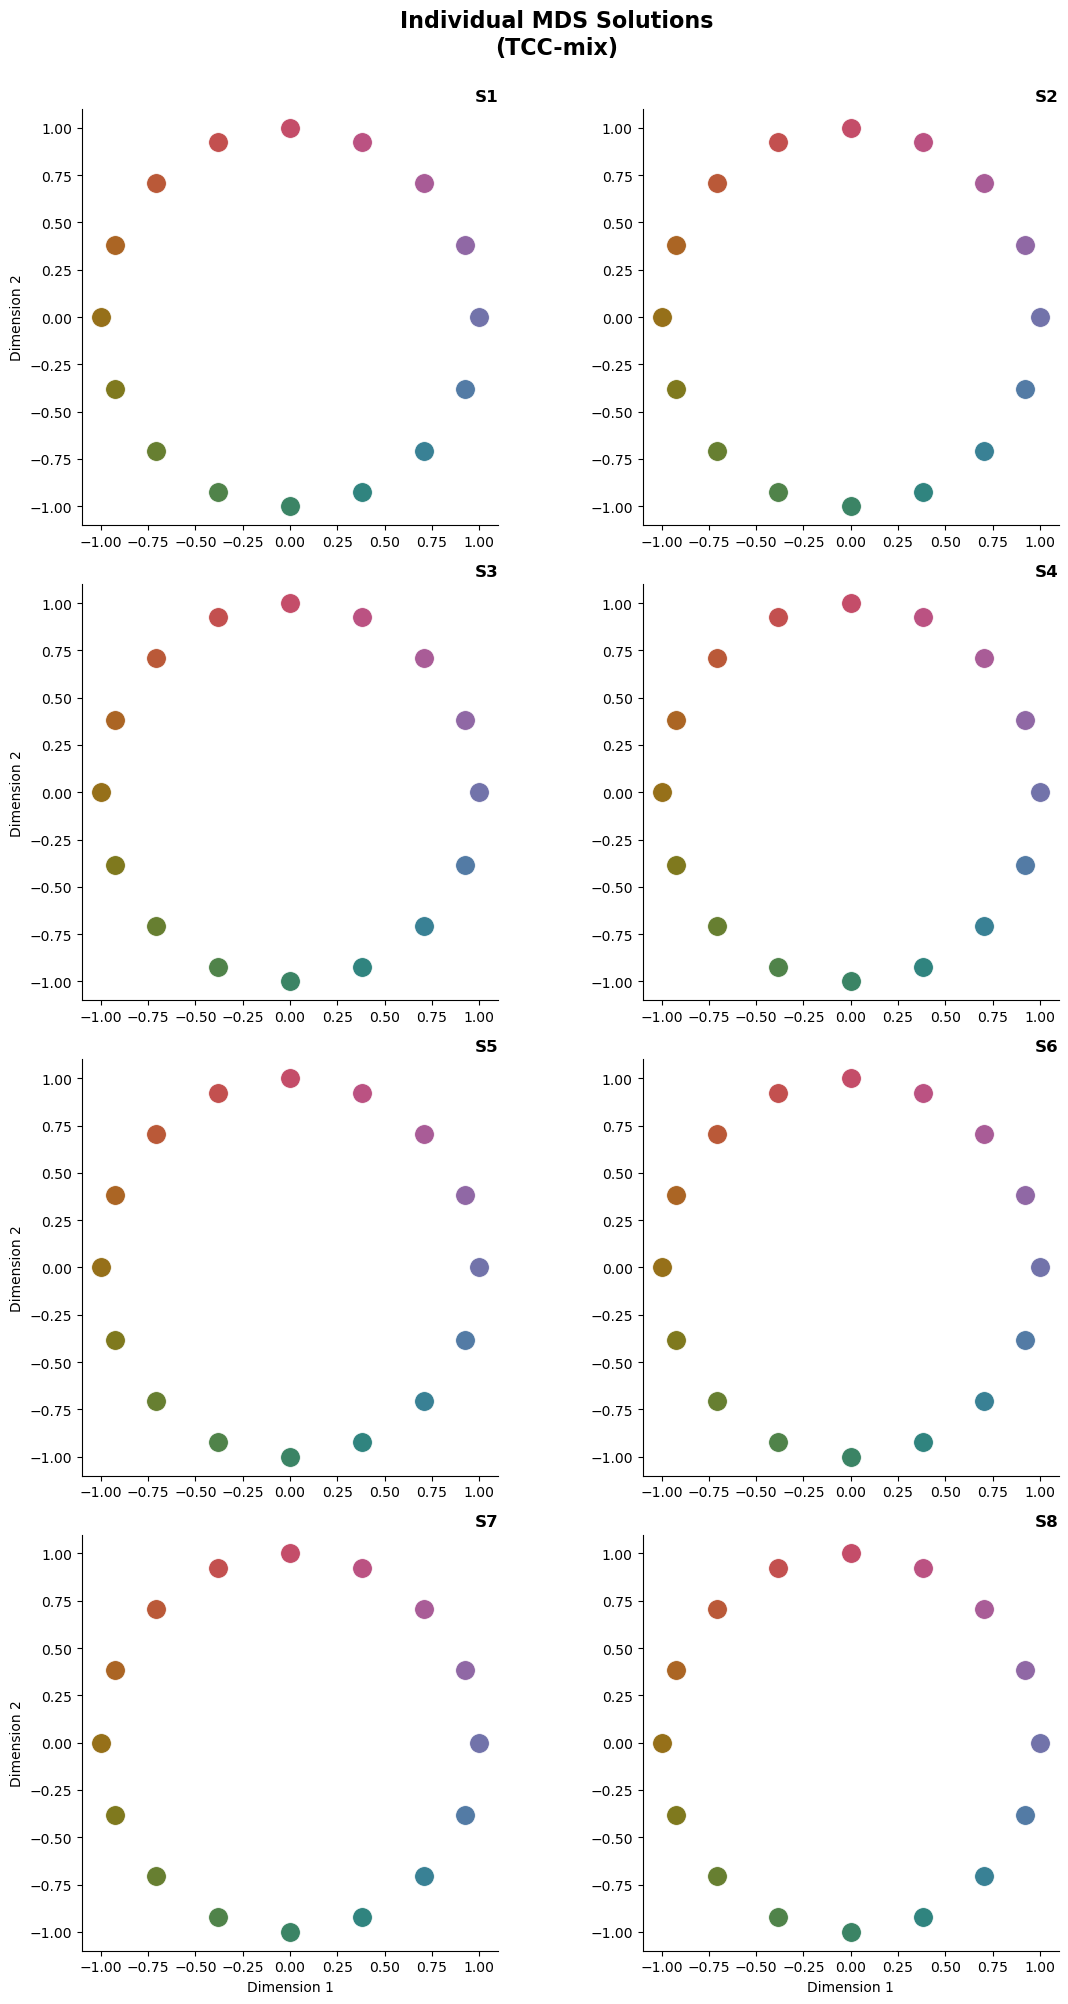

In [148]:
# Plot individual MDS solutions
unpack_funcs = {
    'SCM':     lambda x: unpack_SCM_params(x, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS),
    'SCM-mix': lambda x: unpack_SCM_mix_params(x, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS),
    'TCC':     lambda x: unpack_TCC_params(x, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS),
    'TCC-mix': lambda x: unpack_TCC_mix_params(x, mds_fixed=USE_SINGLE_MDS_SOLUTION, n_subjects=N_SUBJECTS)
    }

for name, fit in models_fit.items():
    plot_mds_solutions(
        fit=fit,
        subjects=SUBJECTS,
        item_colors=item_colors,
        mds_fixed=USE_SINGLE_MDS_SOLUTION,
        unpack_func=unpack_funcs[name],
        model_name=name,
        save_path=PLOTS_PATH
    )

# Save results

In [149]:
# Collect everything
results = {
    'fits': {
        'SCM':     SCM_fit,
        'SCM-mix': SCM_mix_fit,
        'TCC':     TCC_fit,
        'TCC-mix': TCC_mix_fit,
    },
    'predictions': {
        'SCM':     SCM_predictions,
        'SCM-mix': SCM_mix_predictions,
        'TCC':     TCC_predictions,
        'TCC-mix': TCC_mix_predictions,
    },
    'correlations': correlations,
    'comparison': comparison_df,
    'config': {
        'SUBJECTS':   SUBJECTS,
        'SET_SIZES':  SET_SIZES,
        'POSITIONS':  POSITIONS,
        'N_POINTS':   N_POINTS,
        'X_RANGE':    X_RANGE,
    }
}

In [150]:
# Save if needed
if SAVE_RESULTS:
    os.makedirs(PATH, exist_ok=True)

    # --- pickle ---
    pickle_path = os.path.join(PATH, 'results.pkl')
    with open(pickle_path, 'wb') as f:
        pickle.dump(results, f)
    print(f'Saved pickle: {pickle_path}')

    # --- human-readable text ---
    txt_path = os.path.join(PATH, 'results.txt')

    def write_coords(f, coords, subjects):
        if coords.ndim == 2:                               # (16, 2) fixed
            for i, (x, y) in enumerate(coords):
                f.write(f'  Item {i+1:2d}: ({x:.4f}, {y:.4f})\n')
        else:                                              # (n_subj, 16, 2) free
            for s, subj in enumerate(subjects):
                f.write(f'  Subject {subj}:\n')
                for i, (x, y) in enumerate(coords[s]):
                    f.write(f'    Item {i+1:2d}: ({x:.4f}, {y:.4f})\n')

    with open(txt_path, 'w') as f:

        # --- config ---
        f.write(f'Subjects: {list(SUBJECTS)}\n')
        f.write(f'Set sizes: {SET_SIZES}\n')
        f.write(f'Positions: {POSITIONS}\n')
        f.write(f'MDS: {"fixed (unit circle)" if USE_SINGLE_MDS_SOLUTION else "free (fitted per subject)"}\n')
        f.write(f'TCC integration: n_points={N_POINTS}, x_range={X_RANGE}\n')
        f.write('\n' + '='*60 + '\n')

        # --- model comparison table ---
        f.write('\nMODEL COMPARISON\n')
        f.write('-'*60 + '\n')
        f.write(f"{'Model':<16} {'n_params':<12} {'NLL':<12} {'AIC':<12} {'BIC'}\n")
        f.write('-'*60 + '\n')
        for _, row in comparison_df.iterrows():
            f.write(f"{row['model']:<16} {int(row['K']):<12} {row['NLL']:<12.2f} "
                    f"{row['AIC']:<12.2f} {row['BIC']:.2f}\n")
        
        # --- correlations ---
        f.write('\n' + '='*60 + '\n')
        f.write('\nCORRELATIONS (predicted vs observed)\n')

        for model_name, corr_df in results['correlations'].items():
            f.write('\n' + '-'*40 + '\n')
            f.write(f'{model_name}\n')
            f.write('-'*40 + '\n')
            f.write(f"{'Condition':<20} {'r':<10} {'p-value'}\n")
            for _, row in corr_df.iterrows():
                f.write(f"SS={int(row['set_size'])}, Pos={int(row['position']):<8} "
                        f"r={row['r']:.3f}    p={row['p']:.3f}\n")
            mean_r = corr_df['r'].mean()
            f.write(f"Mean r: {mean_r:.3f}\n")

        # --- per-model parameters ---
        f.write('\n' + '='*60 + '\n')
        f.write('\nPER-MODEL PARAMETERS\n')
        for model_name, fit in results['fits'].items():
            f.write('\n' + '-'*60)
            f.write(f'\n{model_name} — best-fitting parameters\n')
            f.write('-'*60 + '\n')
            f.write(f'Loss normalized (as fitted): {fit.fun:.6f}\n')
            f.write(f'Loss de-normalized (NLL, N={total_counts}): {fit.fun * total_counts:.2f}\n')
            f.write(f'Optimizer message: {fit.message}\n\n')

            mds_fixed  = USE_SINGLE_MDS_SOLUTION
            n_subjects = N_SUBJECTS

            if model_name == 'SCM':
                biases, B, c, coords = unpack_SCM_params(
                    fit.x, mds_fixed=mds_fixed, n_subjects=n_subjects)
                f.write('Biases:\n')
                for i, b in enumerate(biases):
                    f.write(f'  Item {i+1:2d}: {b:.4f}\n')
                f.write(f'Boost B: {B:.4f}\n')
                f.write('c per set size:\n')
                for ss, cv in zip(SET_SIZES, c):
                    f.write(f'  SS={ss}: {cv:.4f}\n')
                if not mds_fixed:
                    f.write('MDS coordinates (fitted):\n')
                    write_coords(f, coords, list(SUBJECTS))

            elif model_name == 'SCM-mix':
                biases, B, c, p_mem, gamma, coords = unpack_SCM_mix_params(
                    fit.x, mds_fixed=mds_fixed, n_subjects=n_subjects)
                f.write('Biases:\n')
                for i, b in enumerate(biases):
                    f.write(f'  Item {i+1:2d}: {b:.4f}\n')
                f.write(f'Boost B: {B:.4f}\n')
                f.write('c per set size:\n')
                for ss, cv in zip(SET_SIZES, c):
                    f.write(f'  SS={ss}: {cv:.4f}\n')
                f.write('p_mem per set size:\n')
                for ss, pm in zip(SET_SIZES, p_mem):
                    f.write(f'  SS={ss}: {pm:.4f}\n')
                f.write(f'Gamma: {gamma:.4f}\n')
                if not mds_fixed:
                    f.write('MDS coordinates (fitted):\n')
                    write_coords(f, coords, list(SUBJECTS))

            elif model_name == 'TCC':
                d_prime_base, d_scales, c, biases, hp_boost, coords = \
                    unpack_TCC_params(fit.x, mds_fixed=mds_fixed, n_subjects=n_subjects)
                f.write(f"Base d': {d_prime_base:.4f}\n")
                f.write("d' scales per set size:\n")
                for ss, scale in zip(SET_SIZES, d_scales):
                    f.write(f"  SS={ss}: {scale:.4f}  (d'={d_prime_base*scale:.4f})\n")
                f.write(f'c: {c:.4f}\n')
                f.write('Biases:\n')
                for i, b in enumerate(biases):
                    f.write(f'  Item {i+1:2d}: {b:.4f}\n')
                f.write(f'HP boost: {hp_boost:.4f}\n')
                if not mds_fixed:
                    f.write('MDS coordinates (fitted):\n')
                    write_coords(f, coords, list(SUBJECTS))

            elif model_name == 'TCC-mix':
                d_prime_base, d_scales, c, biases, hp_boost, p_mem, gamma, coords = \
                    unpack_TCC_mix_params(fit.x, mds_fixed=mds_fixed, n_subjects=n_subjects)
                f.write(f"Base d': {d_prime_base:.4f}\n")
                f.write("d' scales per set size:\n")
                for ss, scale in zip(SET_SIZES, d_scales):
                    f.write(f"  SS={ss}: {scale:.4f}  (d'={d_prime_base*scale:.4f})\n")
                f.write(f'c: {c:.4f}\n')
                f.write('Biases:\n')
                for i, b in enumerate(biases):
                    f.write(f'  Item {i+1:2d}: {b:.4f}\n')
                f.write(f'HP boost: {hp_boost:.4f}\n')
                f.write('p_mem per set size:\n')
                for ss, pm in zip(SET_SIZES, p_mem):
                    f.write(f'  SS={ss}: {pm:.4f}\n')
                f.write(f'Gamma: {gamma:.4f}\n')
                if not mds_fixed:
                    f.write('MDS coordinates (fitted):\n')
                    write_coords(f, coords, list(SUBJECTS))
            
        # For fixed MDS, we still want to report the coordinates 
        # (which are the same for all models and subjects)
        if mds_fixed:
            f.write('\n' + '='*60 + '\n')
            f.write('\nMDS COORDINATES (for all models and subjects):\n\n')
            coords = init_coords_circle(N_ITEMS).reshape(N_ITEMS, 2)
            write_coords(f, coords, list([0]))  # just label as "Subject 0" since it's the same for all

    print(f'Saved text: {txt_path}')

Saved pickle: results/Fixed_MDS/results.pkl
Saved text: results/Fixed_MDS/results.txt
